In [ ]:
import pandas as pd
import numpy as np

#Load dataset
merged_data_file_path = r'C:\Users\zezar\TilburgUniversity\Spring2026-TIC\data\feature_matrix.csv'
merged_data = pd.read_csv(merged_data_file_path)

#Drop unnecessary columns
cols_to_drop = [col for col in merged_data.columns if 'locnan' in col]
cols_to_drop += ['date', 'bin', 'ret', 'ecm_spread', 'z_score', 
                 'ecm_spread_lag1', 'ecm_spread_lag2', 
                 'corn_Close', 'soybean_Close','corn_Volume', 
                 'soybean_Volume', 'corn_log_return', 'soybean_log_return']
df_clean = merged_data.drop(columns=cols_to_drop)

#Keep only numeric columns
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
df_numeric = df_clean[numeric_cols]

#Handle missing values
#Drop columns with >50% missing values
df_numeric = df_numeric.loc[:, df_numeric.isna().mean() < 0.5]
#Drop rows where more than 30% of features are missing
df_numeric = df_numeric.dropna(thresh=int(0.7 * df_numeric.shape[1]))
#Fill remaining missing values with column mean
df_numeric = df_numeric.fillna(df_numeric.mean())


print(f"Number of features after cleaning: {df_numeric.shape[1]}")
print(f"Number of rows after cleaning: {df_numeric.shape[0]}")
print(df_numeric.head())


Number of features after cleaning: 118
Number of rows after cleaning: 5246
   temperature_2m_mean_loc1.0  temperature_2m_mean_loc2.0  \
0                    0.390500                    7.551250   
1                   -0.940750                    7.767918   
2                   -1.942833                    8.486667   
3                    2.811333                   13.780417   
4                    7.442583                   10.847084   

   temperature_2m_mean_loc3.0  precipitation_sum_loc1.0  \
0                    5.203417                 52.799995   
1                    7.572166                 11.000001   
2                   11.097168                  0.000000   
3                   10.599249                  0.000000   
4                    9.172167                 32.500000   

   precipitation_sum_loc2.0  precipitation_sum_loc3.0  \
0                  0.000000                       0.8   
1                  0.000000                       0.0   
2                 30.800001     

In [7]:
#Standardize features 
from sklearn.preprocessing import StandardScaler
df_scaled = StandardScaler().fit_transform(df_numeric)
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)

print(f"Number of features after cleaning: {df_scaled.shape[1]}")
print(f"Number of rows after cleaning: {df_scaled.shape[0]}")
print(df_scaled.head())

Number of features after cleaning: 118
Number of rows after cleaning: 5246
   temperature_2m_mean_loc1.0  temperature_2m_mean_loc2.0  \
0                   -1.065765                   -2.047080   
1                   -1.194241                   -2.005276   
2                   -1.290951                   -1.866599   
3                   -0.832134                   -0.845212   
4                   -0.385180                   -1.411175   

   temperature_2m_mean_loc3.0  precipitation_sum_loc1.0  \
0                   -1.080477                  7.708202   
1                   -0.654187                  1.237255   
2                   -0.019814                 -0.465626   
3                   -0.109422                 -0.465626   
4                   -0.366245                  4.565613   

   precipitation_sum_loc2.0  precipitation_sum_loc3.0  \
0                 -0.194160                 -0.291523   
1                 -0.194160                 -0.515036   
2                  6.236307     

In [ ]:
#PCA 
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(df_scaled)
pca_data = pca.transform(df_scaled)

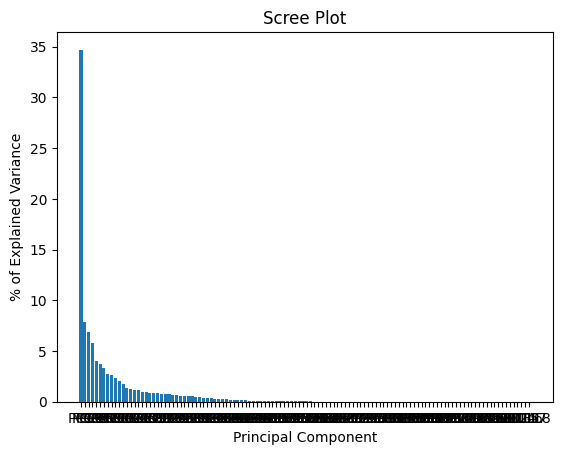

In [13]:
#Scree plot to see how many components should go into the final plot
import matplotlib.pyplot as plt

per_var = np.round(pca.explained_variance_ratio_*100, decimals=1)
labels = ['PC' + str(x) for x in range(1,len(per_var)+1)]

plt.bar(x=range(1, len(per_var)+1), height=per_var, tick_label=labels)
plt.ylabel('% of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()